## Hyperparameter Tuning

In [1]:
# Imports

import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Libraries loaded successfully')

/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/fraudetection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully


In [2]:
# Load Data

X_train = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/data/train dataset/X_train.csv')
X_test = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/data/test dataset/X_test.csv')
y_train = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/data/train dataset/y_train.csv')
y_test = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/data/test dataset/y_test.csv')


print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'\nClass distribution in y_train:\n{y_train.value_counts()}')

X_train shape: (8000, 15)
X_test shape:  (2000, 15)

Class distribution in y_train:
is_fraud
0           7600
1            400
Name: count, dtype: int64


In [3]:
# Objective function for Optuna optimization

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10.0, 30.0),
        'random_state': 42,
        'tree_method': 'hist',
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )

    return scores.mean()

In [4]:
# Run Optuna optimization

study = optuna.create_study(direction='maximize', study_name='xgboost_fraud_detection')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest trial: {study.best_trial.number}')
print(f'Best Recall (CV): {study.best_value:.4f}') 
print(f'\nBest hyperparameters:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

Best trial: 46. Best value: 0.99: 100%|██████████| 100/100 [00:18<00:00,  5.50it/s] 


Best trial: 46
Best Recall (CV): 0.9900

Best hyperparameters:
  n_estimators: 102
  max_depth: 10
  learning_rate: 0.026456174095216303
  subsample: 0.9738819937839506
  colsample_bytree: 0.952865525915632
  gamma: 0.1716706065684041
  reg_lambda: 3.5056324925244335
  reg_alpha: 0.9690970197662319
  min_child_weight: 5
  scale_pos_weight: 28.307413733839365


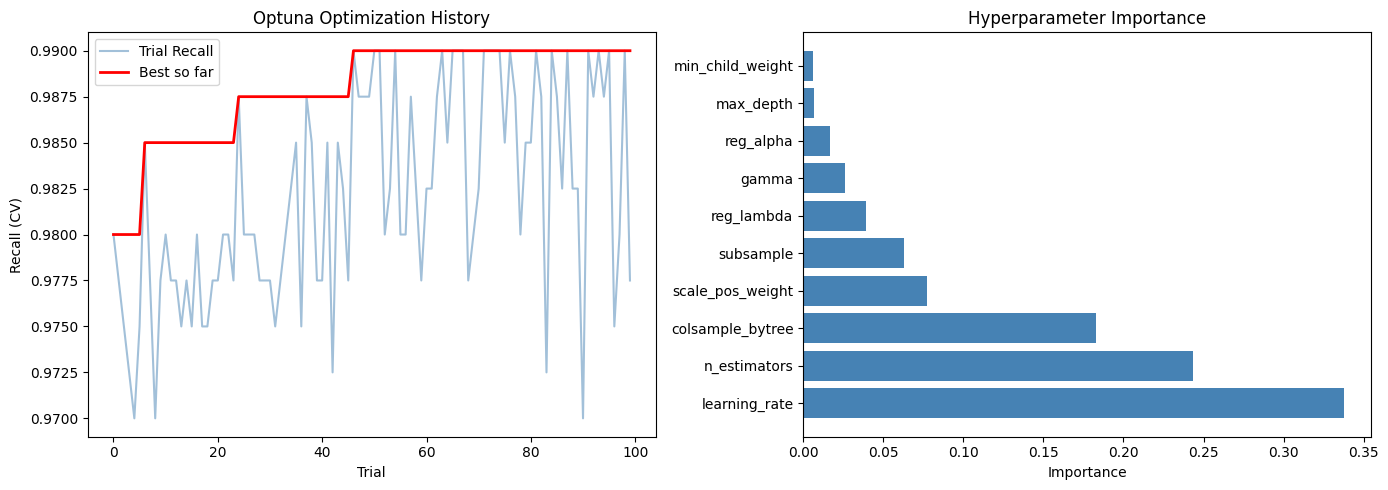

In [7]:
# Visualize Optune results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, alpha=0.5, color='steelblue', label='Trial Recall')
axes[0].plot(pd.Series(trial_values).cummax(), color='red', linewidth=2, label='Best so far')
axes[0].set_title('Optuna Optimization History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Recall (CV)')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_title('Hyperparameter Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [8]:
# Train final model

best_params = study.best_params
best_params['random_state'] = 42
best_params['tree_method']  = 'hist'
best_params['eval_metric']  = 'logloss'

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

print('Final model trained successfully.')

Final model trained successfully.


In [9]:
# Evaluate final model on test set

y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1900
           1       0.87      0.98      0.92       100

    accuracy                           0.99      2000
   macro avg       0.93      0.99      0.96      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score: 0.9956


                  Precision  Recall  F1-Score  Accuracy
Model                                                  
Baseline XGBoost     0.9400    0.92    0.9300    0.9900
Tuned XGBoost        0.8673    0.98    0.9202    0.9915


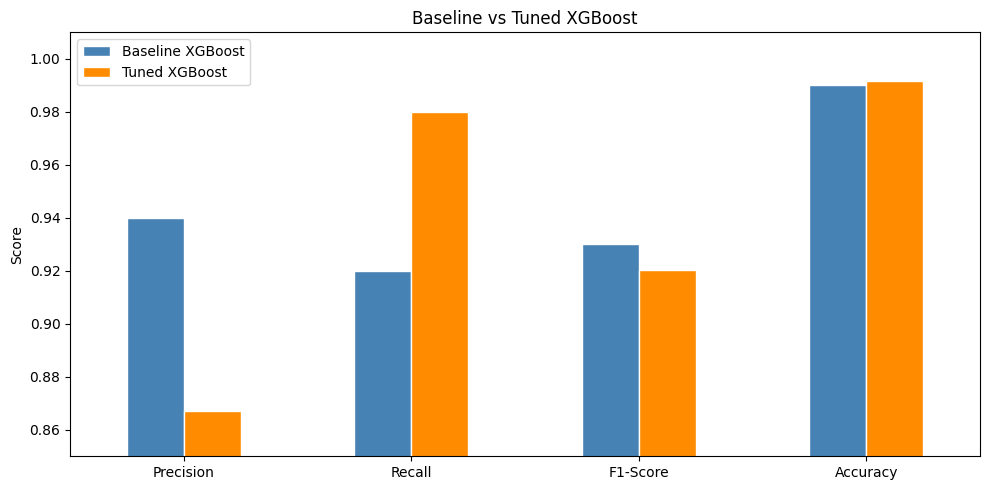

In [10]:
# Compare Baseline vs Tunned Model


baseline = {
    'Model':     'Baseline XGBoost',
    'Precision': 0.94,
    'Recall':    0.92,
    'F1-Score':  0.93,
    'Accuracy':  0.99
}

tuned = {
    'Model':     'Tuned XGBoost',
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'Accuracy':  accuracy_score(y_test, y_pred)
}

comparison = pd.DataFrame([baseline, tuned]).set_index('Model')
print(comparison.round(4))

comparison.T.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'], edgecolor='white')
plt.title('Baseline vs Tuned XGBoost')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.85, 1.01)
plt.legend()
plt.tight_layout()
plt.show()

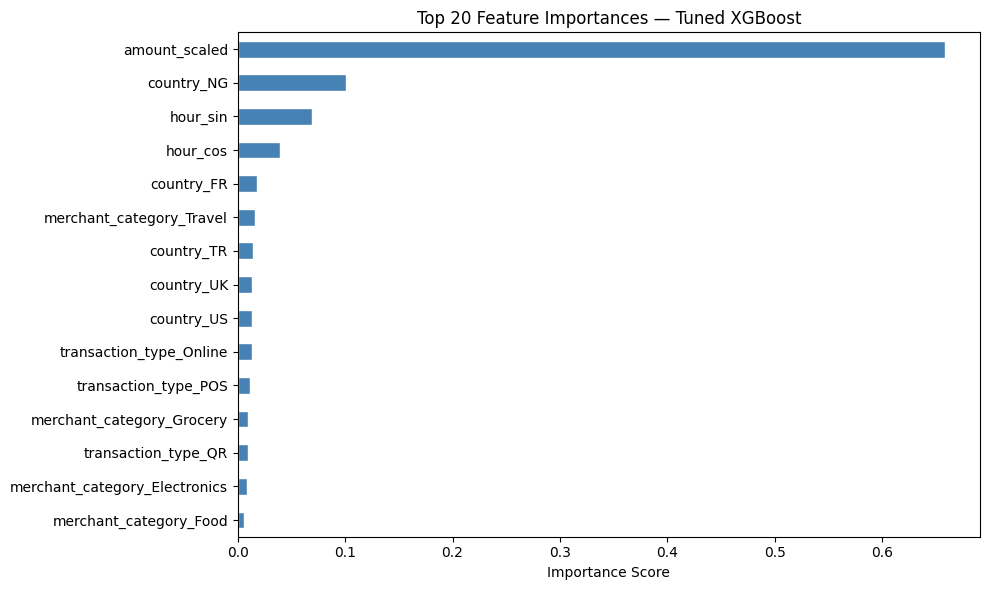

In [11]:
# Feature importance

feat_imp = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importances — Tuned XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
# Save final model and optuna study

joblib.dump(final_model, '/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/models/xgboost_final_model.pkl')
joblib.dump(study,       '/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/models/optuna_study.pkl')

print('Model Saved Successfully.')

Model Saved Successfully.
